In [1]:
import librosa
import matplotlib.pyplot as plt
import librosa.display
import os
import numpy as np
from tensorflow.keras import layers
from IPython.display import Audio
import wave
import pandas as pd
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt

2024-10-27 20:16:13.830591: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-27 20:16:13.841201: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-27 20:16:13.844550: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-27 20:16:13.853957: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-27 20:16:14.459419: W tensorflow/compiler/tf2

In [2]:
df = pd.read_csv("../data_processing/sep28k-mfcc.csv")

In [3]:
df = df[df['NaturalPause'] == 0]
df = df[df['Interjection'] == 0]
df = df[df['Prolongation'] == 0]
df = df[df['WordRep'] == 0]
df = df[df['SoundRep'] == 0]
df.head()

,Show,EpId,ClipId,Start,Stop,Unsure,PoorAudioQuality,Prolongation,Block,SoundRep,...,29,30,31,32,33,34,35,36,37,38
2,HeStutters,0,2,34809760,34857760,0,0,0,0,0,...,-3.249218,-3.218731,0.360520,-0.115838,1.723229,-1.460772,-1.430723,-1.429669,-0.178196,-3.046811
4,HeStutters,0,4,35721920,35769920,0,0,0,0,0,...,-2.057481,-3.225782,-1.561315,-3.723942,-2.249673,-3.513439,-2.097951,-1.940040,0.020210,-0.556461
6,HeStutters,0,6,37251200,37299200,0,0,0,0,0,...,-4.985494,-6.181957,-2.396787,-6.544606,-2.319257,-3.688410,-0.221778,-1.690031,0.664374,-0.303436
9,HeStutters,0,9,41417440,41465440,0,0,0,0,0,...,-4.798577,-6.274436,-4.889234,-5.795599,-4.400376,-4.176473,-0.957432,-3.210292,0.577023,1.042720
11,HeStutters,0,11,42928800,42976800,0,0,0,0,0,...,-3.798326,-6.705790,-1.544637,-6.356187,-0.987506,-3.107216,-1.422836,-3.615824,-1.171095,-1.937332


In [4]:
df = df.reset_index()
df.head()

,index,Show,EpId,ClipId,Start,Stop,Unsure,PoorAudioQuality,Prolongation,Block,...,29,30,31,32,33,34,35,36,37,38
0,2,HeStutters,0,2,34809760,34857760,0,0,0,0,...,-3.249218,-3.218731,0.360520,-0.115838,1.723229,-1.460772,-1.430723,-1.429669,-0.178196,-3.046811
1,4,HeStutters,0,4,35721920,35769920,0,0,0,0,...,-2.057481,-3.225782,-1.561315,-3.723942,-2.249673,-3.513439,-2.097951,-1.940040,0.020210,-0.556461
2,6,HeStutters,0,6,37251200,37299200,0,0,0,0,...,-4.985494,-6.181957,-2.396787,-6.544606,-2.319257,-3.688410,-0.221778,-1.690031,0.664374,-0.303436
3,9,HeStutters,0,9,41417440,41465440,0,0,0,0,...,-4.798577,-6.274436,-4.889234,-5.795599,-4.400376,-4.176473,-0.957432,-3.210292,0.577023,1.042720
4,11,HeStutters,0,11,42928800,42976800,0,0,0,0,...,-3.798326,-6.705790,-1.544637,-6.356187,-0.987506,-3.107216,-1.422836,-3.615824,-1.171095,-1.937332


In [5]:
df = df.drop(columns=['index'])
df.head()

,Show,EpId,ClipId,Start,Stop,Unsure,PoorAudioQuality,Prolongation,Block,SoundRep,...,29,30,31,32,33,34,35,36,37,38
0,HeStutters,0,2,34809760,34857760,0,0,0,0,0,...,-3.249218,-3.218731,0.360520,-0.115838,1.723229,-1.460772,-1.430723,-1.429669,-0.178196,-3.046811
1,HeStutters,0,4,35721920,35769920,0,0,0,0,0,...,-2.057481,-3.225782,-1.561315,-3.723942,-2.249673,-3.513439,-2.097951,-1.940040,0.020210,-0.556461
2,HeStutters,0,6,37251200,37299200,0,0,0,0,0,...,-4.985494,-6.181957,-2.396787,-6.544606,-2.319257,-3.688410,-0.221778,-1.690031,0.664374,-0.303436
3,HeStutters,0,9,41417440,41465440,0,0,0,0,0,...,-4.798577,-6.274436,-4.889234,-5.795599,-4.400376,-4.176473,-0.957432,-3.210292,0.577023,1.042720
4,HeStutters,0,11,42928800,42976800,0,0,0,0,0,...,-3.798326,-6.705790,-1.544637,-6.356187,-0.987506,-3.107216,-1.422836,-3.615824,-1.171095,-1.937332


In [6]:
df.to_csv("block.csv",index=False)

In [7]:
import os

def list_files(directory):
    return [f for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))]

# Replace 'directory_path' with the path to your directory
directory_path = '/home/alien/Git/DATA/mel_spects_block'
# names_list = list_files(directory_path)
names_list = pd.read_csv("block.csv")['Name'].values.tolist()
# full_names_list = ["/home/alien/Git/DATA/mfcc_images/" + img + ".jpg" for img in names_list]
full_names_list = []
for img in names_list:
    corresponding_sound = df.loc[df['Name'] == img, 'Block'].values[0]
    if corresponding_sound == 0:
        full_names_list.append("/home/alien/Git/DATA/mel_spects_block/" + img + "_fluent.jpg")
    if corresponding_sound >= 1:
        full_names_list.append("/home/alien/Git/DATA/mel_spects_block/" + img + "_stutter.jpg")

print(full_names_list[-2])

/home/alien/Git/DATA/mel_spects_block/WomenWhoStutter_109_33_fluent.jpg


In [8]:
def load_all(imagefile_list):
    data = []
    labels = []

    for imagefile in imagefile_list:
        print(imagefile)
        image = cv2.imread(imagefile)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (224, 224))
        data.append(image)

        if "fluent" in imagefile:
            labels.append(0)
        else:
            labels.append(1)

    labels = np.array(labels)
    data = np.array(data)

    return data, labels

In [9]:
X, y = load_all(full_names_list)

/home/alien/Git/DATA/mel_spects_block/HeStutters_0_2_fluent.jpg
/home/alien/Git/DATA/mel_spects_block/HeStutters_0_4_fluent.jpg
/home/alien/Git/DATA/mel_spects_block/HeStutters_0_6_fluent.jpg
/home/alien/Git/DATA/mel_spects_block/HeStutters_0_9_fluent.jpg
/home/alien/Git/DATA/mel_spects_block/HeStutters_0_11_fluent.jpg
/home/alien/Git/DATA/mel_spects_block/HeStutters_0_12_fluent.jpg
/home/alien/Git/DATA/mel_spects_block/HeStutters_0_14_stutter.jpg
/home/alien/Git/DATA/mel_spects_block/HeStutters_0_15_fluent.jpg
/home/alien/Git/DATA/mel_spects_block/HeStutters_0_16_fluent.jpg
/home/alien/Git/DATA/mel_spects_block/HeStutters_0_20_fluent.jpg
/home/alien/Git/DATA/mel_spects_block/HeStutters_0_22_fluent.jpg
/home/alien/Git/DATA/mel_spects_block/HeStutters_0_24_fluent.jpg
/home/alien/Git/DATA/mel_spects_block/HeStutters_0_26_fluent.jpg
/home/alien/Git/DATA/mel_spects_block/HeStutters_0_29_fluent.jpg
/home/alien/Git/DATA/mel_spects_block/HeStutters_0_32_fluent.jpg
/home/alien/Git/DATA/mel_spe

In [10]:
print(X[0])
print(y[0])

[[[ 68  33  60]
  [ 96  28  68]
  [ 89  27  67]
  ...
  [  0   0   4]
  [  0   0   4]
  [  0   0   2]]

 [[114  57  88]
  [166  57 117]
  [157  55 112]
  ...
  [  0   0   4]
  [  0   0   4]
  [  0   0   2]]

 [[140  60  94]
  [190  55 118]
  [198  65 126]
  ...
  [  0   0   4]
  [  0   0   4]
  [  0   0   2]]

 ...

 [[126  65 103]
  [194  56 123]
  [189  69 128]
  ...
  [ 29  13  72]
  [ 18   5  59]
  [ 21   6  57]]

 [[ 90  48 102]
  [145  31 116]
  [141  39 122]
  ...
  [ 26  18  68]
  [ 24  17  63]
  [ 27  19  61]]

 [[ 86  33  88]
  [122  36 120]
  [134  36 131]
  ...
  [ 23  14  63]
  [ 27  18  70]
  [ 26  14  66]]]
0


In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size=0.3, random_state=12)

In [12]:
print("x_train shape:", X_train.shape)
print("x_test shape:", X_test.shape)
print('y_train shape:', y_train.shape)
print("y_test shape:", y_test.shape)

x_train shape: (1829, 224, 224, 3)
x_test shape: (784, 224, 224, 3)
y_train shape: (1829,)
y_test shape: (784,)


In [13]:
print(len(X_train), len(X_test), len(y_train), len(y_test))

1829 784 1829 784


In [14]:
from collections import Counter
print(Counter(y_train))
print(Counter(y_test))

Counter({0: 1189, 1: 640})
Counter({0: 509, 1: 275})


In [15]:
print(X_train)

[[[[  0   0   2]
   [  0   0   2]
   [  0   0   2]
   ...
   [  0   0   2]
   [  0   0   4]
   [  0   0   2]]

  [[  0   0   2]
   [  0   0   2]
   [  0   0   2]
   ...
   [  0   0   2]
   [  0   0   4]
   [  0   0   2]]

  [[  0   0   2]
   [  0   0   2]
   [  0   0   2]
   ...
   [  0   0   2]
   [  0   0   2]
   [  0   0   2]]

  ...

  [[ 51  20  72]
   [ 66  19 120]
   [ 79  29 119]
   ...
   [193  67 128]
   [185  60 128]
   [180  64 130]]

  [[ 32  18  57]
   [ 42  16  99]
   [ 38  12  83]
   ...
   [142  36 113]
   [146  41 122]
   [148  43 121]]

  [[ 28  13  55]
   [ 38  17  89]
   [ 25  10  63]
   ...
   [131  36 121]
   [139  41 125]
   [137  39 121]]]


 [[[  0   0   2]
   [  0   0   2]
   [  0   0   2]
   ...
   [ 29  12  60]
   [ 28  11  58]
   [ 29  13  54]]

  [[  0   0   2]
   [  0   0   2]
   [  0   0   2]
   ...
   [ 46  24  96]
   [ 47  25  98]
   [ 43  22  90]]

  [[  0   0   2]
   [  0   0   2]
   [  0   0   2]
   ...
   [ 20   6  54]
   [ 24   9  61]
   [ 23   8

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.metrics import accuracy_score
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, MultiHeadAttention
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dropout, Flatten, Dense, Input, AveragePooling2D, Attention, Reshape, TimeDistributed, Bidirectional, LSTM
from tensorflow.keras.models import Model
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from keras.preprocessing import image
from keras.applications.vgg16 import preprocess_input, decode_predictions
from sklearn.metrics import classification_report, confusion_matrix

In [17]:
vgg_model = tf.keras.models.load_model('./model_block_AUGMENT.keras')

I0000 00:00:1730074578.813202   26836 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1730074578.838966   26836 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1730074578.843731   26836 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1730074578.850401   26836 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

In [18]:
vgg_model.summary

<bound method Model.summary of <Functional name=functional, built=True>>

In [19]:
# Combine features
X_combined = np.concatenate((X_train, X_test), axis=0)

# Combine labels
y_combined = np.concatenate((y_train, y_test), axis=0)
# predictions
vgg_pred = vgg_model.predict(X_combined, batch_size=1)

vgg_pred = np.round(vgg_pred)

  # model evaluation
confusion = confusion_matrix(y_combined, vgg_pred)
print(classification_report(y_combined, vgg_pred))
print(confusion)

2024-10-27 20:16:20.479408: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907
W0000 00:00:1730074580.533150   27057 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1730074580.548021   27057 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1730074580.550552   27057 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1730074580.550963   27057 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1730074580.552002   27057 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1730074580.553266   27057 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1730074580.554376   27057 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1730074580.554802   27057 gpu_t

2613/2613 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1698
           1       0.94      0.92      0.93       915

    accuracy                           0.95      2613
   macro avg       0.95      0.94      0.94      2613
weighted avg       0.95      0.95      0.95      2613

[[1640   58]
 [  74  841]]


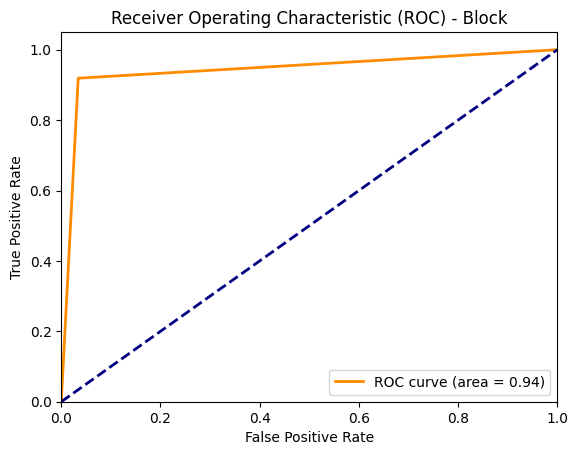

In [20]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming vgg_pred contains probabilities of belonging to class 1
fpr, tpr, thresholds = roc_curve(y_combined, vgg_pred)

# Calculate the area under the curve (AUC)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Block')
plt.legend(loc="lower right")
plt.show()